# We want to find some biological meaning from integration and prediction results

In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
adata = sc.read_h5ad('./Apexigen_data/Apexigen_gene_TCR_annotated_for_integration_real_case.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 16286 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3'
    obsm: 'X_umap'
    layers: 'counts'

In [4]:
tissue_meta_data = pd.read_csv('./Apexigen_data/PBMC_tumor_metadata_TCR_match.csv', index_col=0)

In [5]:
tissue_meta_data

,TRB_barcode,TRB_is_cell,TRB_contig_id,TRB_high_confidence,TRB_length,TRB_chain,TRB_v_gene,TRB_d_gene,TRB_j_gene,TRB_c_gene,...,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,tissue
1,AAACCTGAGGCGCTCT-1,True,AAACCTGAGGCGCTCT-1_contig_2,True,499,TRB,TRBV9,NaN,TRBJ1-2,TRBC1,...,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,PBMC
3,AAACCTGCATGCCACG-1,True,AAACCTGCATGCCACG-1_contig_2,True,507,TRB,TRBV7-9,NaN,TRBJ2-2,TRBC2,...,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,PBMC
4,AAACCTGTCTCCTATA-1,True,AAACCTGTCTCCTATA-1_contig_2,True,799,TRB,TRBV3-1,NaN,TRBJ1-5,TRBC1,...,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,PBMC
5,AAACGGGAGGGATACC-1,True,AAACGGGAGGGATACC-1_contig_1,True,499,TRB,TRBV7-2,NaN,TRBJ2-1,TRBC2,...,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,PBMC
7,AAACGGGCATCGGAAG-1,True,AAACGGGCATCGGAAG-1_contig_2,True,517,TRB,TRBV5-5,NaN,TRBJ2-7,TRBC2,...,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,PBMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22920,TTTCCTCCACTCGACG-1,True,TTTCCTCCACTCGACG-1_contig_1,True,681,TRB,TRBV5-1,NaN,TRBJ1-2,TRBC1,...,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,tumor
22921,TTTGCGCGTGTGCCTG-1,True,TTTGCGCGTGTGCCTG-1_contig_1,True,698,TRB,TRBV12-3,NaN,TRBJ2-5,TRBC1,...,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,tumor
22922,TTTGGTTCACCAGCAC-1,True,TTTGGTTCACCAGCAC-1_contig_1,True,521,TRB,TRBV6-5,TRBD1,TRBJ2-3,TRBC2,...,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,tumor
22923,TTTGGTTGTTCTGGTA-1,True,TTTGGTTGTTCTGGTA-1_contig_1,True,690,TRB,TRBV7-9,NaN,TRBJ1-6,TRBC1,...,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,tumor


In [6]:
adata.obs['tissue'] = tissue_meta_data['tissue'].values

In [7]:
adata.obs

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,tissue
AAACCTGAGGCGCTCT-1-4,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,PBMC
AAACCTGCATGCCACG-1-4,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,PBMC
AAACCTGTCTCCTATA-1-6,6,1825.0,864,HD,HD_01,HD,HD_03,nan,7.509336,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,PBMC
AAACGGGAGGGATACC-1-8,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,PBMC
AAACGGGCATCGGAAG-1-3,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,PBMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCCACTCGACG-1_05_post,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,tumor
TTTGCGCGTGTGCCTG-1_05_post,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,tumor
TTTGGTTCACCAGCAC-1_05_post,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,tumor
TTTGGTTGTTCTGGTA-1_05_post,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,tumor


In [8]:
ED_integration_gex_tcr_df = pd.DataFrame(np.load(f"ED_integration_batch_gex_tcr_embeddings_train_Apexigen.npy" ))
ED_integration_gex_tcr_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.097965,-5.564989,0.681142,6.984371,-0.734428,-0.423449,-2.334072,-2.407746,0.760507,6.712961,...,-0.752272,-1.013509,3.737686,-0.841155,0.254238,-4.846057,5.821734,-0.796591,4.792559,1.597013
1,0.228618,-1.183873,1.744123,0.648499,-5.800107,-0.462475,0.986755,-2.599211,-2.870118,7.579226,...,1.490718,-3.260944,0.985154,-1.728886,-0.634036,-5.549471,0.095191,2.620960,1.132539,0.627408
2,-0.077231,-2.486963,0.572366,1.522991,-3.761447,0.408589,0.058475,-3.452749,-0.247325,5.508348,...,1.595478,-3.298505,0.703353,-1.993700,0.412777,-6.049917,2.659121,3.007093,1.491285,1.402891
3,-1.059989,-2.501665,0.186317,-2.818088,-7.689115,0.695106,1.849355,-3.643781,0.229575,4.440676,...,-2.077902,-0.907624,-0.106975,-4.373280,-0.728662,-2.301482,-2.872865,5.049060,0.718591,0.278997
4,0.432945,-3.628826,-1.222166,1.852195,-5.127234,-1.387731,-0.588211,-5.835842,2.578338,6.163433,...,-0.384060,-3.754251,2.646099,-4.112102,-2.611930,-4.727805,1.428691,2.616744,0.289052,2.934578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16281,1.840736,-2.889653,-1.761791,4.100647,-5.112239,0.039093,-0.449976,-3.555399,0.847613,6.244727,...,-1.728399,-1.990157,2.848830,-1.532704,-2.286174,-4.808550,4.086527,0.888382,0.487844,2.284950
16282,-1.518533,-4.179431,-0.386524,2.492806,-1.663755,-2.443689,0.700026,-4.383622,1.213836,2.875041,...,-0.035483,-2.650346,-0.968119,-0.982020,-3.445464,-0.597582,2.909247,1.059798,2.973114,0.543933
16283,-1.704261,-3.892424,1.229959,1.612291,-1.250120,1.156884,-1.378860,-0.714496,-0.027560,5.308167,...,0.138738,0.109283,3.412722,-2.069978,0.462392,-5.014590,2.419384,1.761374,3.440462,-1.460231
16284,0.051483,-1.659687,-0.898965,3.045621,-2.618190,-2.043929,0.094440,-1.963590,-1.695406,5.688796,...,1.622939,-3.073576,3.471458,-0.637571,-2.127196,-3.460937,2.848315,0.811334,1.895361,0.467532


In [9]:
Apexigen_emb = ad.AnnData(ED_integration_gex_tcr_df, obs=adata.obs)
Apexigen_emb

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 16286 × 64
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'tissue'

In [10]:
sc.tl.pca(Apexigen_emb,svd_solver='arpack')
sc.pp.neighbors(Apexigen_emb, n_neighbors = 15, n_pcs=45)
sc.tl.leiden(Apexigen_emb, resolution=0.8)

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/opt/homebrew/Caskroom/min

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


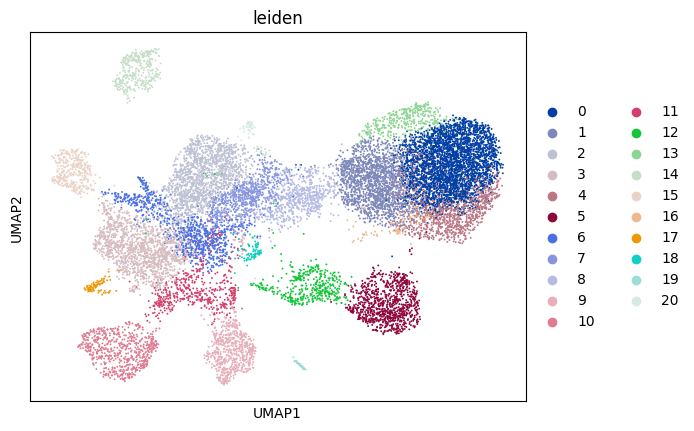

In [11]:
sc.tl.umap(Apexigen_emb)
sc.pl.umap(Apexigen_emb, color=['leiden'])

In [12]:
Apexigen_emb.obs.columns

Index(['batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response',
       'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class',
       'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3',
       'TRA_cdr3', 'tissue', 'leiden'],
      dtype='object')

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


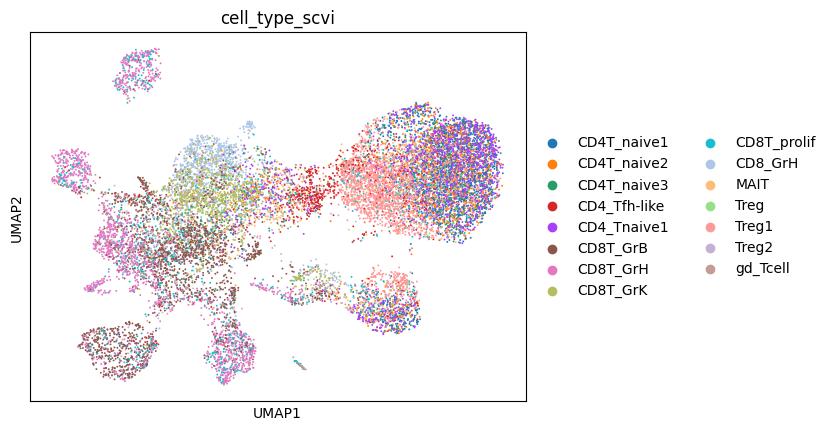

In [13]:
sc.pl.umap(Apexigen_emb, color=['cell_type_scvi'])

In [14]:
Apexigen_emb.obs['sample'].value_counts()


sample
03_pre        3085
02_post       2853
05_pre        2081
04_post       1774
HD_03         1335
03_post       1074
01_pre         885
05_post        475
HD_02          460
HD_01          427
04_surgery     270
06_pre         235
02_surgery     208
01_surgery     199
01_LTF2        174
04_pre         144
01_post        122
03_LTF2        112
04_LTF2         76
03_surgery      68
02_pre          65
05_LTF3         51
05_surgery      41
06_surgery      39
06_post         33
Name: count, dtype: int64

In [15]:
Apexigen_emb_no_HC = Apexigen_emb[~Apexigen_emb.obs['sample'].str.contains("HD")].copy()
Apexigen_emb_no_HC = Apexigen_emb_no_HC[~Apexigen_emb_no_HC.obs['cell_type_scvi'].isnull()]

In [16]:
Apexigen_emb_no_HC.obs['tissue'].value_counts()

tissue
tumor    11002
PBMC      3062
Name: count, dtype: int64

In [17]:
Apexigen_emb_no_HC.obs['timepoint'].value_counts()

timepoint
pre_CD40     6495
post_CD40    6331
surgery       825
follow_up     413
Name: count, dtype: int64

In [18]:
Apexigen_emb_no_HC.obs['timepoint'].value_counts(normalize=True)

timepoint
pre_CD40     0.461817
post_CD40    0.450156
surgery      0.058660
follow_up    0.029366
Name: proportion, dtype: float64

In [19]:
Apexigen_emb_no_HC.obs['patient'].value_counts()

patient
03    4339
02    3126
05    2648
04    2264
01    1380
06     307
Name: count, dtype: int64

In [20]:
Apexigen_emb_no_HC.obs['patient'].value_counts(normalize=True)

patient
03    0.308518
02    0.222270
05    0.188282
04    0.160978
01    0.098123
06    0.021829
Name: proportion, dtype: float64

In [21]:
Apexigen_emb_no_HC.obs[['patient','timepoint']].groupby('patient')['timepoint'].value_counts()

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_60761/1336978252.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Apexigen_emb_no_HC.obs[['patient','timepoint']].groupby('patient')['timepoint'].value_counts()


patient  timepoint
01       pre_CD40      885
         surgery       199
         follow_up     174
         post_CD40     122
02       post_CD40    2853
         surgery       208
         pre_CD40       65
         follow_up       0
03       pre_CD40     3085
         post_CD40    1074
         follow_up     112
         surgery        68
04       post_CD40    1774
         surgery       270
         pre_CD40      144
         follow_up      76
05       pre_CD40     2081
         post_CD40     475
         follow_up      51
         surgery        41
06       pre_CD40      235
         surgery        39
         post_CD40      33
         follow_up       0
Name: count, dtype: int64

In [22]:
Apexigen_emb_no_HC.obs['sample'].value_counts()

sample
03_pre        3085
02_post       2853
05_pre        2081
04_post       1774
03_post       1074
01_pre         885
05_post        475
04_surgery     270
06_pre         235
02_surgery     208
01_surgery     199
01_LTF2        174
04_pre         144
01_post        122
03_LTF2        112
04_LTF2         76
03_surgery      68
02_pre          65
05_LTF3         51
05_surgery      41
06_surgery      39
06_post         33
Name: count, dtype: int64

In [23]:
Apexigen_emb_no_HC.obs['tissue'].value_counts(normalize=True)

tissue
tumor    0.782281
PBMC     0.217719
Name: proportion, dtype: float64

In [25]:
sc.pp.highly_variable_genes(adata)
adata_HVG = adata[:,adata.var['highly_variable']]
sc.pp.pca(adata_HVG)
sc.external.pp.harmony_integrate(adata_HVG, 'sample')

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
2026-04-07 20:10:29,851 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-07 20:10:39,429 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-07 20:10:39,493 - harmonypy - INFO - Iteration 1 of 10
2026-04-07 20:10:46,575 - harmonypy - INFO - Iteration 2 of 10
2026-04-07 20:10:53,793 - harmonypy - INFO - Iteration 3 of 10
2026-04-07 20:11:00,837 - harmonypy - INFO - Iteration 4 of 10
2026-04-07 20:11:08,043 - harmonypy - INFO - Iteration 5 of 10
2026-04-07 20:11:14,727 - harmonypy - INFO - Converged after 5 iterations


/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


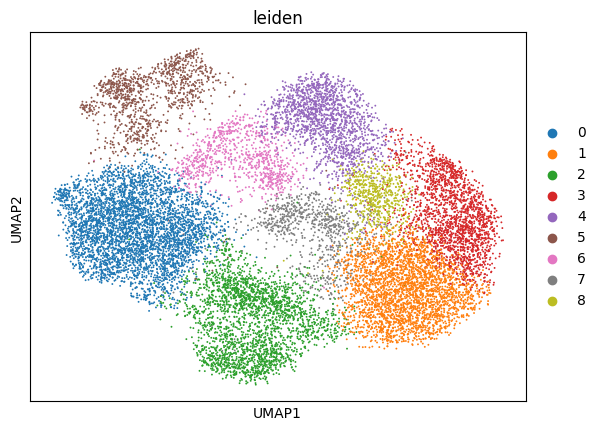

In [27]:
sc.pp.neighbors(adata_HVG, n_neighbors = 15, n_pcs=45, use_rep="X_pca_harmony")
sc.tl.leiden(adata_HVG, resolution=0.8)
sc.tl.umap(adata_HVG)
sc.pl.umap(adata_HVG, color=['leiden'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

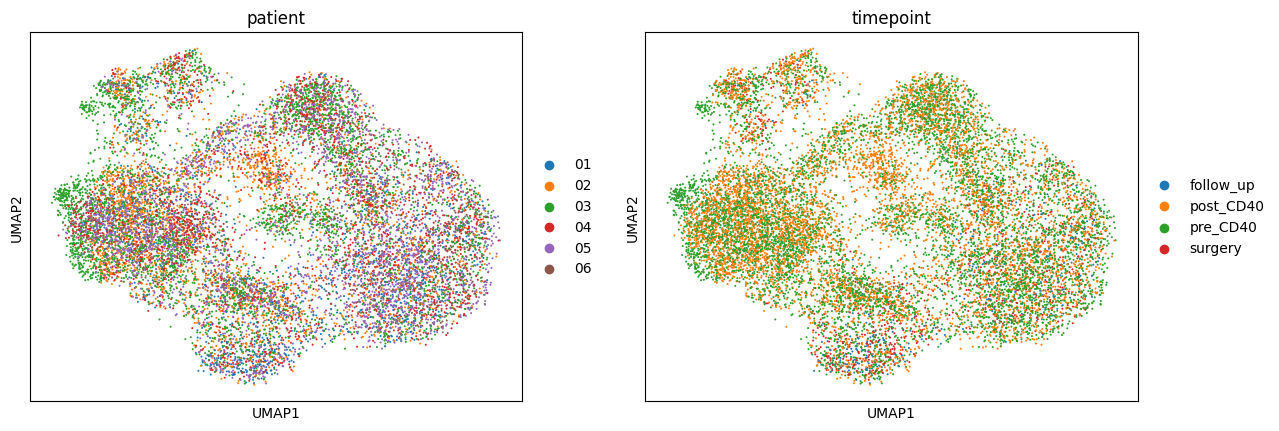

In [32]:
sc.pl.umap(adata_HVG_no_HC, color=['patient','timepoint'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

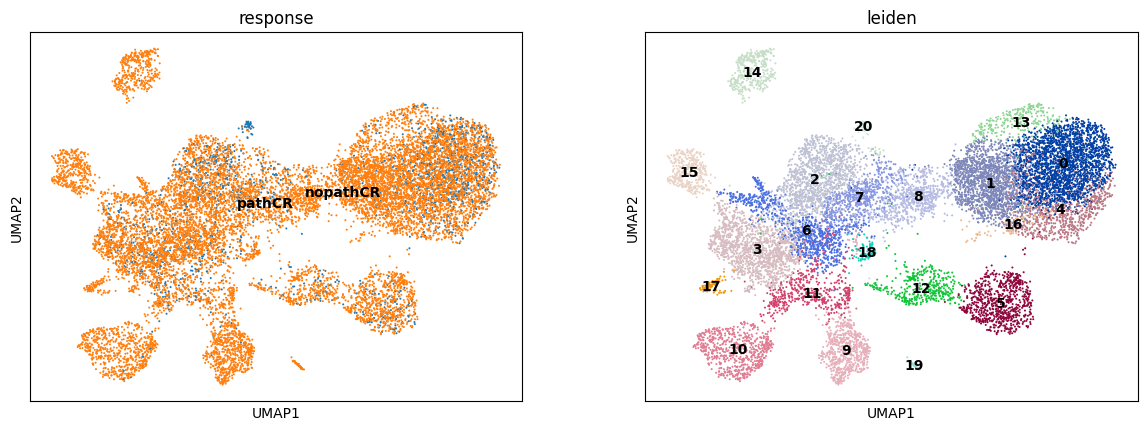

In [34]:
sc.pl.umap(Apexigen_emb_no_HC, color=['response','leiden'], legend_loc="on data")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


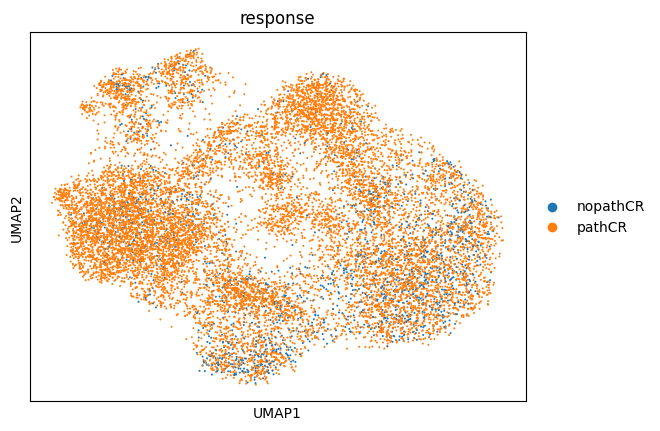

In [35]:
sc.pl.umap(adata_HVG_no_HC, color=['response'])

In [49]:
Apexigen_emb_no_HC.obs

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,tissue,leiden
AAACCTGAGGCGCTCT-1-4,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,PBMC,0
AAACCTGCATGCCACG-1-4,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,PBMC,4
AAACGGGAGGGATACC-1-8,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,PBMC,20
AAACGGGCATCGGAAG-1-3,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,PBMC,0
AAACGGGGTACCGAGA-1-2,2,2106.0,905,CR,03,pathCR,03_pre,pre_CD40,7.652546,0.073599,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPPGSFGYGYTF,CAVTWGSSNTGKLIF,PBMC,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCCACTCGACG-1_05_post,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,tumor,0
TTTGCGCGTGTGCCTG-1_05_post,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,tumor,3
TTTGGTTCACCAGCAC-1_05_post,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,tumor,0
TTTGGTTGTTCTGGTA-1_05_post,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,tumor,4


/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

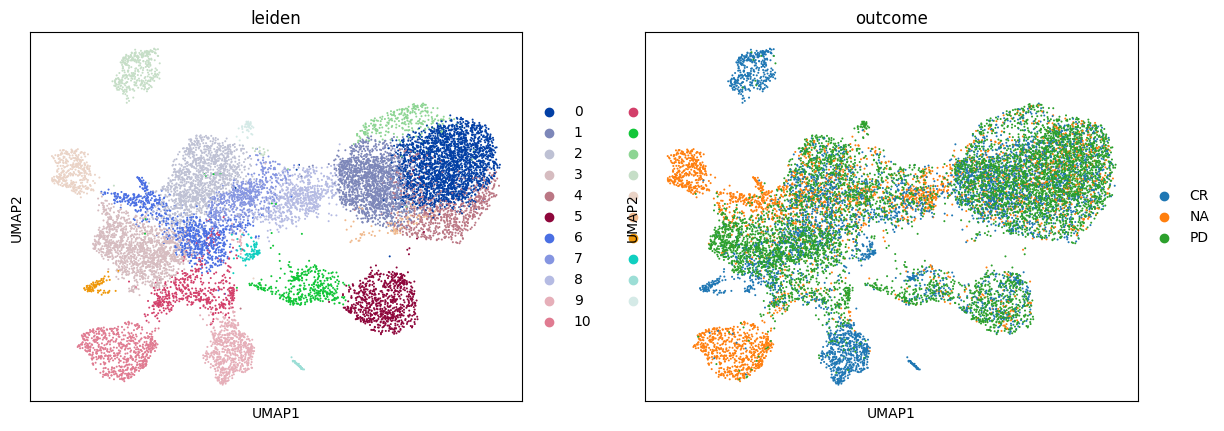

In [50]:
sc.pl.umap(Apexigen_emb_no_HC, color=['leiden','outcome'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


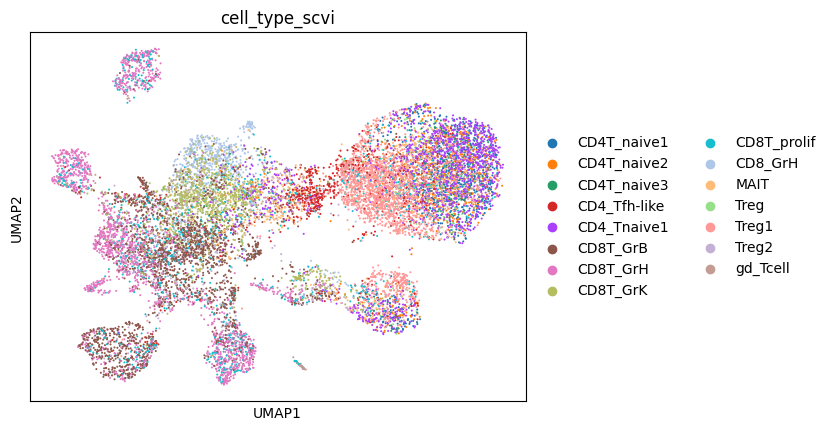

In [51]:
sc.pl.umap(Apexigen_emb_no_HC, color=['cell_type_scvi'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

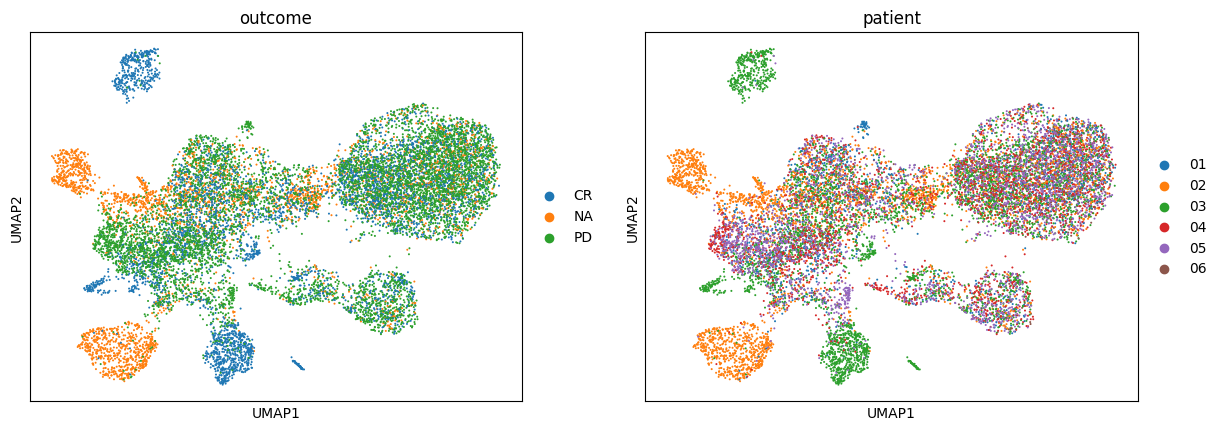

In [52]:
sc.pl.umap(Apexigen_emb_no_HC, color=['outcome','patient'])

In [64]:
cytotoxic_genes = [
    "PRF1",   # perforin
    "GZMB", "GZMA", "GZMH",  # granzymes
    "GNLY",   # granulysin
    "NKG7"
]

In [65]:
cytotoxic_extended = [
    "PRF1", "GZMB", "GZMA", "GZMK", "GZMH",
    "GNLY", "NKG7",
    "IFNG", "TNF",
    "KLRD1", "KLRK1"
]

In [66]:
exhaustion_genes = [
    "PDCD1",  # PD-1
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2",  # TIM-3
    "TOX"
]

In [67]:
tumor_reactive = [
    "CXCL13", "PDCD1", "TOX", "ICOS", "LAG3"
]

In [68]:
nk_killing = [
    "PRF1", "GZMB", "GNLY",
    "NKG7", "KLRK1", "FCGR3A"
]

In [70]:
# mask = adata.obs["cell_type"].astype(str).str.contains("CD8T", na=False)
adata_t = adata.copy()
adata_t = adata_t[~adata_t.obs['patient'].str.contains("HD")]


In [72]:
sc.tl.score_genes(adata_t, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_t, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_t, tumor_reactive, score_name="tumor_reactive")
sc.tl.score_genes(adata_t, nk_killing, score_name="nk_killing")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


In [74]:
# mask = Apexigen_emb_no_HC.obs["cell_type"].astype(str).str.contains("CD8T", na=False)
Apexigen_emb_no_HC_t = Apexigen_emb_no_HC.copy()

In [75]:
Apexigen_emb_no_HC_t.obs[['cytotoxic','exhaustion','tumor_reactive','nk_killing']] = adata_t[Apexigen_emb_no_HC_t.obs.index].obs[['cytotoxic','exhaustion','tumor_reactive','nk_killing']]

In [76]:
Apexigen_emb_no_HC_t.obs.columns


Index(['batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response',
       'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class',
       'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3',
       'TRA_cdr3', 'tissue', 'leiden', 'IFN_score', 'cytotoxic', 'exhaustion',
       'tumor_reactive', 'nk_killing'],
      dtype='object')

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


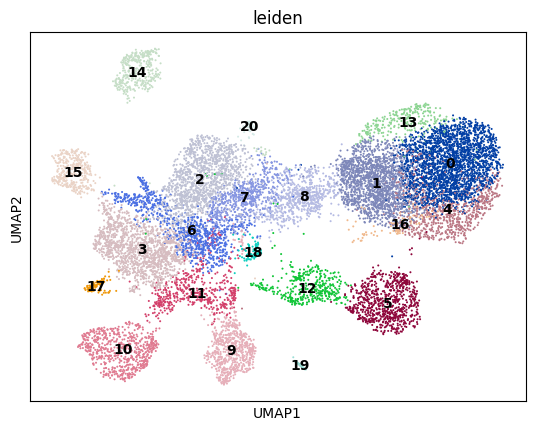

In [78]:
sc.pl.umap(Apexigen_emb_no_HC, color=['leiden'], legend_loc="on data")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


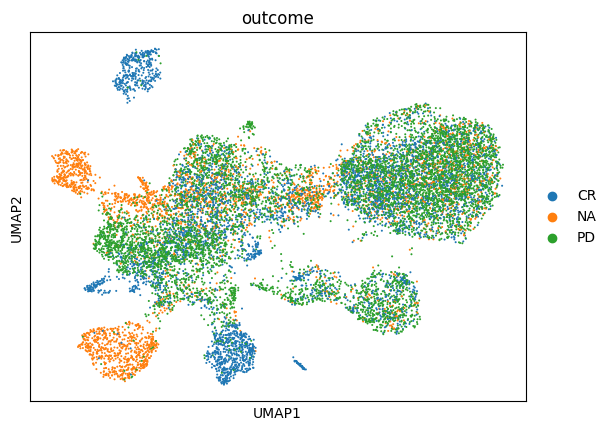

In [82]:
sc.pl.umap(Apexigen_emb_no_HC_t, color=['outcome'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

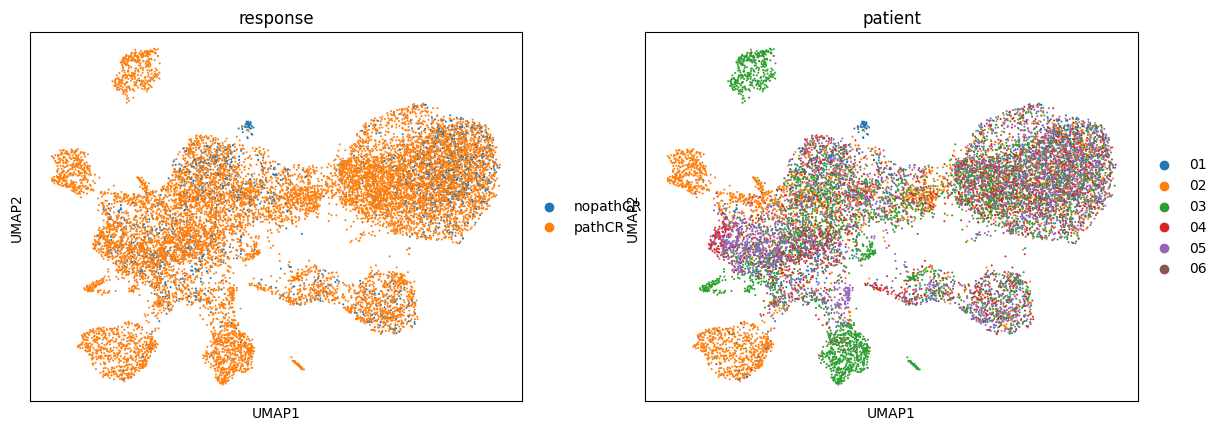

In [83]:
sc.pl.umap(Apexigen_emb_no_HC_t, color=['response','patient'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


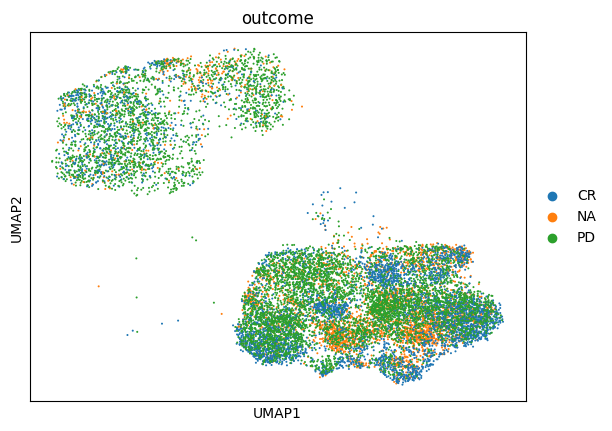

In [86]:
sc.pl.umap(adata_t, color=['outcome'])

In [89]:
import seaborn as sns

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

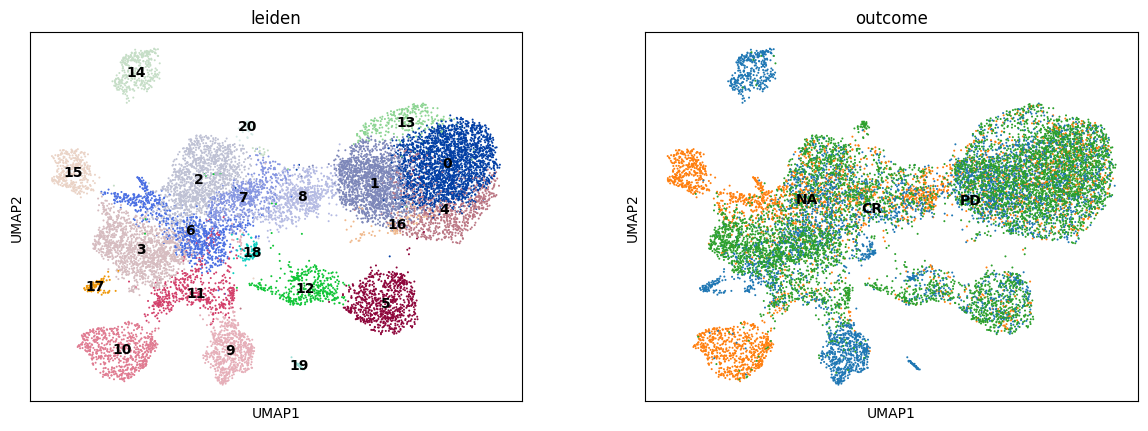

In [97]:
sc.pl.umap(Apexigen_emb_no_HC, color=["leiden",'outcome'], legend_loc="on data")


In [99]:
Apexigen_emb_no_HC_t_CR_PD = Apexigen_emb_no_HC_t[Apexigen_emb_no_HC_t.obs['outcome'].isin(['CR',"PD"])].copy()

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


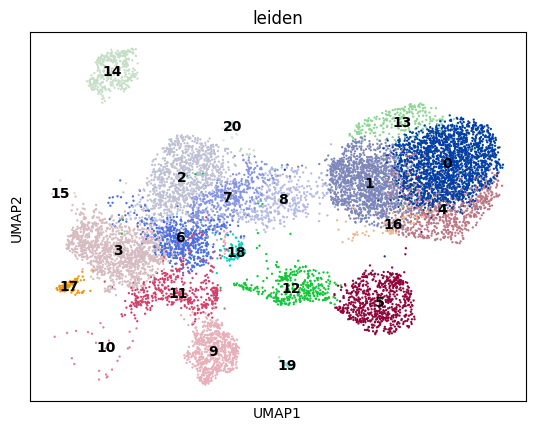

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

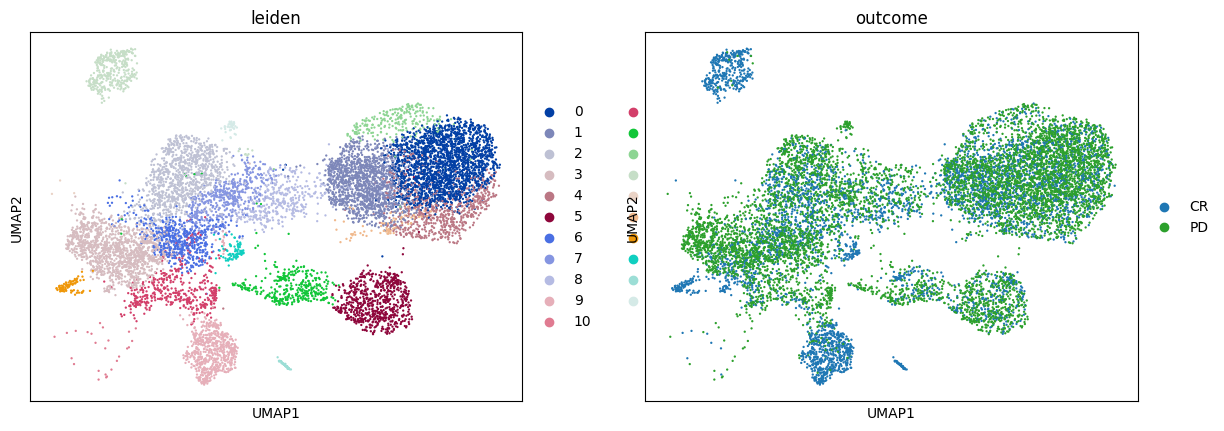

In [100]:
sc.pl.umap(Apexigen_emb_no_HC_t_CR_PD, color=["leiden"], legend_loc="on data")
sc.pl.umap(Apexigen_emb_no_HC_t_CR_PD, color=["leiden",'outcome'])

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


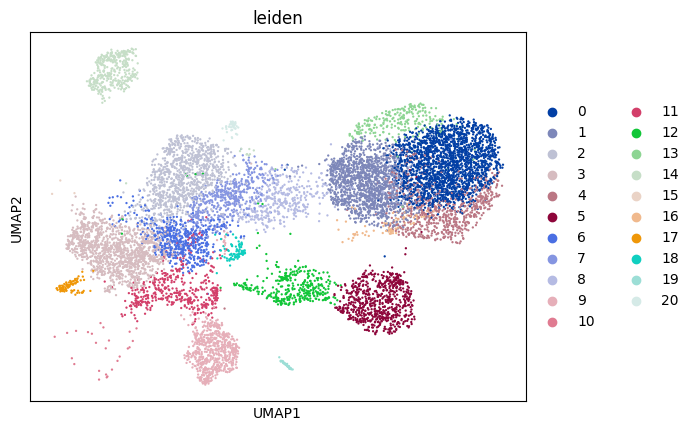

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


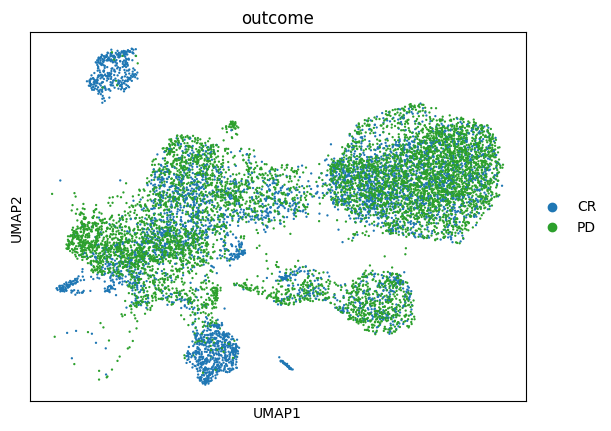

In [101]:
sc.pl.umap(Apexigen_emb_no_HC_t_CR_PD, color=["leiden"])
sc.pl.umap(Apexigen_emb_no_HC_t_CR_PD, color=['outcome'])

In [160]:
Apexigen_exact_match = pd.read_csv('./Apexigen_tumor_paired_train_all_match_res_IEDB_McPAS_VDJdb_085_acc_040726.csv', index_col=0)
Apexigen_exact_match

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
12763056,0,2444.0,1136,CR,03,pathCR,03_pre,pre_CD40,7.801391,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSVVGGDEQYF,CAAWLGGAGSYQLTF,GLCTLVAML,0.026631,CASSVVGGDEQYF_GLCTLVAML
16668739,0,4774.0,2013,PD,01,nopathCR,01_pre,pre_CD40,8.470940,0.000000,3,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSFEETQYF,CAVSNDYKLSF,TAAQAAVVRFQEAAN,0.079082,CASSFEETQYF_TAAQAAVVRFQEAAN
11090757,0,3028.0,1295,PD,05,pathCR,05_post,post_CD40,8.015657,0.000000,2,Treg,Treg,Treg1,Treg,CASSYPNQPQHF,CAASDRGSQGNLIF,LLWNGPMAV,0.143726,CASSYPNQPQHF_LLWNGPMAV
15275502,0,6857.0,2166,PD,05,pathCR,05_pre,pre_CD40,8.833025,0.000000,4,CD8_Tcell,CD8T_prolif,CD8T_GrB,CD8_T,CASSSTDTQYF,CVVSENPDSGYALNF,VISNDVCAQV,0.156714,CASSSTDTQYF_VISNDVCAQV
2418782,0,7633.0,2263,PD,01,nopathCR,01_pre,pre_CD40,8.940236,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSTLAGGTDTQYF,CAVGANYGQNFVF,LLAGIGTVPI,0.159820,CASSTLAGGTDTQYF_LLAGIGTVPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12450014,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FLYALALLL,0.980757,CASSGDGMNTEAFF_FLYALALLL
13084305,0,5933.0,2036,NaN,02,pathCR,02_post,post_CD40,8.688285,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.981446,CASSGDGMNTEAFF_FLYALALLL
17445111,27,3027.0,931,PD,01,nopathCR,01_post,post_CD40,8.015327,0.052527,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSLGGNQPQHF,CAYRSGNDMRF,LPRRSGAAGA,0.981778,CASSLGGNQPQHF_LPRRSGAAGA
10061872,0,4635.0,1935,PD,04,pathCR,04_post,post_CD40,8.441392,0.000000,4,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.987907,CASSLGGSYEQYF_LPRRSGAAGA


In [161]:
Apexigen_exact_match['Epitope'].value_counts()

Epitope
LPRRSGAAGA     42
SLLMWITQV      33
RPHERNGFTVL    20
TPRVTGGGAM     19
FLYALALLL      17
               ..
NLNCCSVPV       1
YVLDHLIVV       1
SSCMGGMNWR      1
YAKWKLCSA       1
ALAGIGILTV      1
Name: count, Length: 63, dtype: int64

In [162]:
Apexigen_exact_match['TRB_cdr3'].value_counts()

TRB_cdr3
CASSYSGSSGELFF     23
CASSLGQGYEQYF      20
CASSPSRNTEAFF      20
CASSGDGMNTEAFF     17
CASSPDRVETQYF      12
                   ..
CASSPTGGTGELFF      1
CASSLGTDTQYF        1
CASSLMDTDTQYF       1
CASSPGSLAKNIQYF     1
CASSLGGDSPLHF       1
Name: count, Length: 111, dtype: int64

In [163]:
Apexigen_exact_match['cell_class_scvi'].value_counts()

cell_class_scvi
CD8_T         156
Treg           45
CD4T_naive     41
CD4_T          40
Name: count, dtype: int64

In [164]:


# Read the first two rows as plain data
head = pd.read_csv("./Apexigen_data/tcr_full_v3.csv", nrows=2, header=None)

# Build new column names from row 0 and row 1
def combine(a, b, sep="_"):
    a = '' if pd.isna(a) else str(a).strip()
    b = '' if pd.isna(b) else str(b).strip()
    return f"{a}{sep}{b}" if a and b else (a or b)

new_cols = [combine(a, b) for a, b in zip(head.iloc[0], head.iloc[1])]

# Now read the rest, skipping the first two rows, and assign columns
tcr_full = pd.read_csv("Merged_IEDB_McPAS_VDJdb_TCR_peptide_peptide_type.csv")
# tcr_full.columns = new_cols

In [179]:
Apexigen_tumor_paired_train_all_peptide_no_NA = pd.read_csv("Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb_085_acc_040726.csv", index_col=0)
Apexigen_tumor_paired_train_all_peptide_no_NA

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_60761/2029329936.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  Apexigen_tumor_paired_train_all_peptide_no_NA = pd.read_csv("Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb_085_acc_040726.csv", index_col=0)


,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,SLLMWITQC,0.428897,CASSVATAGGIGYTF_SLLMWITQC
1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,AAGIGILTV,0.036122,CASSLGGVNTGELFF_AAGIGILTV
2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,ELAGIGILTV,0.212221,CASSQGGLGLGGAVQPQHF_ELAGIGILTV
3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,YLEPGPVTV,0.004628,CASSRLAEVNEQFF_YLEPGPVTV
4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,YLEPGAVTA,0.373498,CASSAGGARVSYEQYF_YLEPGAVTA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18680037,0,4706.0,1357,PD,5,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,QLCDVMFYL,0.010708,CASSLDSYGYTF_QLCDVMFYL
18680038,0,2891.0,1380,PD,5,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,YLYDRLLRV,0.002353,CASSLSYSEETQYF_YLYDRLLRV
18680039,0,3474.0,1338,PD,5,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,LYPEFIASI,0.111599,CASTQNGGDTQYF_LYPEFIASI
18680040,0,4632.0,1231,PD,5,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,MLIGIPVYV,0.009577,CASSNVRRSRDSPLHF_MLIGIPVYV


In [180]:
Apexigen_meta = pd.read_csv('./Apexigen_data/Apexigen_obs_metadata_for_integration_real_case.csv', index_col=0)
Apexigen_meta

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3
AAACCTGAGGCGCTCT-1-4,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF
AAACCTGCATGCCACG-1-4,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF
AAACCTGTCTCCTATA-1-6,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF
AAACGGGAGGGATACC-1-8,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF
AAACGGGCATCGGAAG-1-3,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCCACTCGACG-1_05_post,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF
TTTGCGCGTGTGCCTG-1_05_post,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF
TTTGGTTCACCAGCAC-1_05_post,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF
TTTGGTTGTTCTGGTA-1_05_post,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF


In [182]:
Apexigen_tumor_paired_train_all_peptide_no_NA['barcode'] = np.tile(Apexigen_meta.index.values,1147)

In [183]:
Apexigen_tumor_paired_train_all_peptide_no_NA['leiden'] = np.tile(Apexigen_emb.obs['leiden'].values,1147)

In [184]:
Apexigen_tumor_paired_train_all_peptide_no_NA

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden
0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,...,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,SLLMWITQC,0.428897,CASSVATAGGIGYTF_SLLMWITQC,AAACCTGAGGCGCTCT-1-4,0
1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,AAGIGILTV,0.036122,CASSLGGVNTGELFF_AAGIGILTV,AAACCTGCATGCCACG-1-4,4
2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,...,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,ELAGIGILTV,0.212221,CASSQGGLGLGGAVQPQHF_ELAGIGILTV,AAACCTGTCTCCTATA-1-6,0
3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,...,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,YLEPGPVTV,0.004628,CASSRLAEVNEQFF_YLEPGPVTV,AAACGGGAGGGATACC-1-8,20
4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,...,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,YLEPGAVTA,0.373498,CASSAGGARVSYEQYF_YLEPGAVTA,AAACGGGCATCGGAAG-1-3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18680037,0,4706.0,1357,PD,5,pathCR,05_post,post_CD40,8.456594,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,QLCDVMFYL,0.010708,CASSLDSYGYTF_QLCDVMFYL,TTTCCTCCACTCGACG-1_05_post,0
18680038,0,2891.0,1380,PD,5,pathCR,05_post,post_CD40,7.969358,0.000000,...,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,YLYDRLLRV,0.002353,CASSLSYSEETQYF_YLYDRLLRV,TTTGCGCGTGTGCCTG-1_05_post,3
18680039,0,3474.0,1338,PD,5,pathCR,05_post,post_CD40,8.153062,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,LYPEFIASI,0.111599,CASTQNGGDTQYF_LYPEFIASI,TTTGGTTCACCAGCAC-1_05_post,0
18680040,0,4632.0,1231,PD,5,pathCR,05_post,post_CD40,8.440744,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,MLIGIPVYV,0.009577,CASSNVRRSRDSPLHF_MLIGIPVYV,TTTGGTTGTTCTGGTA-1_05_post,4


In [185]:
all_3_datasets = pd.read_csv("Merged_IEDB_McPAS_VDJdb_TCR_peptide_peptide_type.csv")

In [186]:
all_3_datasets_peptide_type = all_3_datasets[['Epitope','Epitope_type']].drop_duplicates()
all_3_datasets_peptide_type

,Epitope,Epitope_type
0,SLLMWITQC,Cancer/testis antigen 1
1,AAGIGILTV,Melanoma antigen recognized by T-cells 1
3,ELAGIGILTV,melanoma-specific artificial polyepitopic immu...
4,YLEPGPVTV,NaN
5,YLEPGAVTA,NaN
...,...,...
56800,LYPEFIASI,DPY19L4
56801,MLIGIPVYV,RNF19B
56802,KLYGLDWAEL,ASTN1
56805,ALDPHSGHFV,CDK4


In [187]:
all_3_datasets_peptide_type = all_3_datasets_peptide_type.groupby(['Epitope']).head(1)

In [188]:
all_3_datasets_peptide_type

,Epitope,Epitope_type
0,SLLMWITQC,Cancer/testis antigen 1
1,AAGIGILTV,Melanoma antigen recognized by T-cells 1
3,ELAGIGILTV,melanoma-specific artificial polyepitopic immu...
4,YLEPGPVTV,NaN
5,YLEPGAVTA,NaN
...,...,...
56798,QLCDVMFYL,BRAP
56799,YLYDRLLRV,GINS1
56800,LYPEFIASI,DPY19L4
56801,MLIGIPVYV,RNF19B


In [189]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes = Apexigen_tumor_paired_train_all_peptide_no_NA[Apexigen_tumor_paired_train_all_peptide_no_NA['predicted_binding_probability'] > 0.5]

In [190]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden
7,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,0.041176,...,CD4T_naive3,CD4T_naive1,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,YLEPGPVTA,0.564534,CATSRVAGAGEQFF_YLEPGPVTA,AAAGCAAGTCTCGTTC-1-6,13
10,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,0.022777,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,SLLMWITQV,0.892789,CASIISGVGTDTQYF_SLLMWITQV,AAATGCCGTCAGATAA-1-7,0
28,4,3857.0,1251,PD,05,pathCR,05_post,post_CD40,8.257645,0.050039,...,CD4T_naive3,CD4T_naive1,CD4T_naive,CASSQGLAGRNEQFF,CAVSPITDSWGKLQF,TLWCSPIKV,0.578623,CASSQGLAGRNEQFF_TLWCSPIKV,AACTCTTTCGCCAGCA-1-4,0
36,2,1158.0,526,CR,03,pathCR,03_pre,pre_CD40,7.054450,0.057858,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CASRTGGAHRADTQYF,CAGEEGSARQLTF,RHDLPPYRVYL,0.590237,CASRTGGAHRADTQYF_RHDLPPYRVYL,AAGGCAGGTAACGCGA-1-2,13
43,7,2191.0,749,CR,03,pathCR,03_LTF2,follow_up,7.692113,0.054313,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CSAPFWDGTDTQYF,CASNFGNEKLTF,APRGPHGGAASGA,0.564591,CSAPFWDGTDTQYF_APRGPHGGAASGA,AATCCAGAGAAACCTA-1-7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18679889,0,5295.0,1649,PD,5,pathCR,05_post,post_CD40,8.574518,0.000000,...,CD8T_GrH,CD8T_GrB,CD8_T,CASSSGLAQNEQFF,CALSREGNARLMF,VCGERGFFYT,0.670393,CASSSGLAQNEQFF_VCGERGFFYT,CTCACACAGACAAGCC-1_05_post,11
18679911,0,5229.0,1991,PD,5,pathCR,05_post,post_CD40,8.561976,0.000000,...,Teff/NK,CD8T_GrH,CD8_T,CASSLDPGGTDTQYF,CAVTEREYGNKLVF,ALWGPDPKAA,0.626684,CASSLDPGGTDTQYF_ALWGPDPKAA,GACACGCAGACCCACC-1_05_post,3
18679922,0,4098.0,1464,PD,5,pathCR,05_post,post_CD40,8.318254,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLKPDLFNYGYTF,CAFMKPSTGGKLIF,IYDQVPFSV,0.767266,CASSLKPDLFNYGYTF_IYDQVPFSV,GACTACACATGTTGAC-1_05_post,0
18679938,0,4873.0,1577,PD,5,pathCR,05_post,post_CD40,8.491465,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASAMQPSQETQYF,CAMKGVTSYDKVIF,IMDQVPFSQ,0.700881,CASAMQPSQETQYF_IMDQVPFSQ,GCGCAACAGAGCCTAG-1_05_post,0


In [191]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type = Apexigen_tumor_paired_train_all_peptide_no_NA_yes.merge(all_3_datasets_peptide_type, left_on="Epitope", right_on='Epitope', how="left")
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type
0,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,0.041176,...,CD4T_naive1,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,YLEPGPVTA,0.564534,CATSRVAGAGEQFF_YLEPGPVTA,AAAGCAAGTCTCGTTC-1-6,13,Melanocyte protein PMEL
1,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,0.022777,...,CD4T_naive1,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,SLLMWITQV,0.892789,CASIISGVGTDTQYF_SLLMWITQV,AAATGCCGTCAGATAA-1-7,0,melanoma-specific artificial polyepitopic immu...
2,4,3857.0,1251,PD,05,pathCR,05_post,post_CD40,8.257645,0.050039,...,CD4T_naive1,CD4T_naive,CASSQGLAGRNEQFF,CAVSPITDSWGKLQF,TLWCSPIKV,0.578623,CASSQGLAGRNEQFF_TLWCSPIKV,AACTCTTTCGCCAGCA-1-4,0,NaN
3,2,1158.0,526,CR,03,pathCR,03_pre,pre_CD40,7.054450,0.057858,...,CD4T_naive1,CD4T_naive,CASRTGGAHRADTQYF,CAGEEGSARQLTF,RHDLPPYRVYL,0.590237,CASRTGGAHRADTQYF_RHDLPPYRVYL,AAGGCAGGTAACGCGA-1-2,13,NaN
4,7,2191.0,749,CR,03,pathCR,03_LTF2,follow_up,7.692113,0.054313,...,CD4T_naive1,CD4T_naive,CSAPFWDGTDTQYF,CASNFGNEKLTF,APRGPHGGAASGA,0.564591,CSAPFWDGTDTQYF_APRGPHGGAASGA,AATCCAGAGAAACCTA-1-7,5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025406,0,5295.0,1649,PD,5,pathCR,05_post,post_CD40,8.574518,0.000000,...,CD8T_GrB,CD8_T,CASSSGLAQNEQFF,CALSREGNARLMF,VCGERGFFYT,0.670393,CASSSGLAQNEQFF_VCGERGFFYT,CTCACACAGACAAGCC-1_05_post,11,PREINS
1025407,0,5229.0,1991,PD,5,pathCR,05_post,post_CD40,8.561976,0.000000,...,CD8T_GrH,CD8_T,CASSLDPGGTDTQYF,CAVTEREYGNKLVF,ALWGPDPKAA,0.626684,CASSLDPGGTDTQYF_ALWGPDPKAA,GACACGCAGACCCACC-1_05_post,3,INS
1025408,0,4098.0,1464,PD,5,pathCR,05_post,post_CD40,8.318254,0.000000,...,CD4_Tnaive1,CD4_T,CASSLKPDLFNYGYTF,CAFMKPSTGGKLIF,IYDQVPFSV,0.767266,CASSLKPDLFNYGYTF_IYDQVPFSV,GACTACACATGTTGAC-1_05_post,0,PMEL
1025409,0,4873.0,1577,PD,5,pathCR,05_post,post_CD40,8.491465,0.000000,...,CD4_Tnaive1,CD4_T,CASAMQPSQETQYF,CAMKGVTSYDKVIF,IMDQVPFSQ,0.700881,CASAMQPSQETQYF_IMDQVPFSQ,GCGCAACAGAGCCTAG-1_05_post,0,PMEL


In [192]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type[~Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type['Epitope_type'].isna()]

In [246]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_high_conf = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type[Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type['predicted_binding_probability'] > 0.8]
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_high_conf

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,category
1,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,0.022777,...,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,SLLMWITQV,0.892789,CASIISGVGTDTQYF_SLLMWITQV,AAATGCCGTCAGATAA-1-7,0,melanoma-specific artificial polyepitopic immu...,None
8,6,1463.0,623,HD,HD_01,HD,HD_03,NaN,7.288244,0.058100,...,CD4T_naive,CAWTVAGADEQYF,CAMRRLSNYQLIW,SLLMWITQA,0.920082,CAWTVAGADEQYF_SLLMWITQA,ACCAGTAGTGAGTGAC-1-6,0,NaN,None
9,8,4581.0,1390,PD,01,nopathCR,01_LTF2,follow_up,8.429672,0.067671,...,CD8_T,CASSFRTEGGELFF,CAASSTTSGSRLTF,ELGGIGILTV,0.848319,CASSFRTEGGELFF_ELGGIGILTV,ACGAGCCAGCTTCGCG-1-8,2,NaN,None
10,2,1610.0,586,CR,03,pathCR,03_pre,pre_CD40,7.383989,0.046584,...,CD4T_naive,CSARVPRDEKLFF,CALSGRFSDGQKLLF,FLKGIGWIPI,0.803926,CSARVPRDEKLFF_FLKGIGWIPI,ACGCCGACAGACAAGC-1-2,5,Nebulin,None
15,0,2920.0,939,PD,01,nopathCR,01_pre,pre_CD40,7.979339,0.038356,...,CD4T_naive,CSARGQAETQYF,CAVKPVGFGNVLHC,KPILWRGLK,0.925428,CSARGQAETQYF_KPILWRGLK,CAACTAGCAACTGGCC-1-0,5,Condensin-2 complex subunit G2,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025375,0,3296.0,1274,PD,5,pathCR,05_pre,pre_CD40,8.100465,0.000000,...,CD4_T,CSAIHPGTGGNEQFF,CAADHFGNEKLTF,ILTGLNYEA,0.936056,CSAIHPGTGGNEQFF_ILTGLNYEA,TACCTATAGCCAACAG-1_05_pre,5,Neoantigen,None
1025387,0,2547.0,1124,PD,5,pathCR,05_pre,pre_CD40,7.842671,0.000000,...,CD4_T,CSAPSGRARDTQYF,CALSDQGSARQLTF,TLFTMVGTV,0.868014,CSAPSGRARDTQYF_TLFTMVGTV,TCTCTAATCGTTGACA-1_05_pre,12,Neoantigen,None
1025388,0,2523.0,984,PD,5,pathCR,05_pre,pre_CD40,7.833204,0.000000,...,CD4_T,CSAGGGVIYGYTF,CAGAKGSQGNLIF,SLLLLSVSV,0.929808,CSAGGGVIYGYTF_SLLLLSVSV,TGAGCCGAGTGCCAGA-1_05_pre,5,Neoantigen,None
1025392,0,1927.0,943,PD,5,pathCR,05_pre,pre_CD40,7.563720,0.000000,...,CD8_T,CASSRGGGFTDTQYF,CKLQLLNLETQLSTFVQRLPIL,FSWGAEGQRPGF,0.885452,CASSRGGGFTDTQYF_FSWGAEGQRPGF,TGGTTAGAGAACTGTA-1_05_pre,3,MBP,None


In [247]:
pd.DataFrame(Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_high_conf.groupby(['Epitope','Epitope_type'])['TRB_cdr3'].nunique()).to_csv("Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_count_unique_TCRs_IEDB_McPAS_VDJdb_085_acc_040726.csv")

In [248]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count = pd.DataFrame(Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_high_conf.groupby(['Epitope','Epitope_type'])['TRB_cdr3'].nunique()).reset_index(drop = False)
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count

,Epitope,Epitope_type,TRB_cdr3
0,AAGIGILTV,Melanoma antigen recognized by T-cells 1,1
1,AAKMYAFTL,ZNT8,28
2,AALPILFQV,SF3B1,122
3,AALQRLAAV,PTPRN,12
4,AARAVFLAL,Melanoma,191
...,...,...,...
771,YTAYVFIPI,Serine palmitoyltransferase small subunit B,41
772,YVLDHLIVV,Epstein Barr virus (EBV),50
773,YVLTWIVGA,Neoantigen,21
774,YVMAYVMAGVGS,HER2,2


In [307]:
epitope_type = pd.read_excel("./viral_tumor_others_from_list_by_PL.xlsx", header=None)
epitope_type.columns = ['Epitope_Source Molecule','Type']
epitope_type

,Epitope_Source Molecule,Type
0,Melanoma,Tumor
1,Melanocyte,Tumor
2,Cancer,Tumor
3,Protein SSX,Tumor
4,Glypican-3,Tumor
5,Tyrosinase,Tumor
6,tumor,Tumor
7,GTPase,Tumor
8,Metalloreductase,Tumor
9,Mucin-1,Tumor


In [197]:
cancer_gene = pd.read_csv("./cancer_antigen_genes.csv")
cancer_gene

,Gene,Category,Type
0,MAGEA1,Cancer-Testis Antigen,Tumor
1,MAGEA3,Cancer-Testis Antigen,Tumor
2,MAGEA4,Cancer-Testis Antigen,Tumor
3,MAGEA10,Cancer-Testis Antigen,Tumor
4,MAGE-A1,Cancer-Testis Antigen,Tumor
5,MAGE-A3,Cancer-Testis Antigen,Tumor
6,MAGE-A4,Cancer-Testis Antigen,Tumor
7,MAGE-A10,Cancer-Testis Antigen,Tumor
8,NY-ESO-1,Cancer-Testis Antigen,Tumor
9,CTAG1B,Cancer-Testis Antigen,Tumor


In [198]:
gene_mapping_dict = dict(zip(cancer_gene['Gene'].values,cancer_gene['Type'].values))

In [308]:
mapping_dict = dict(zip(epitope_type['Epitope_Source Molecule'].values,epitope_type['Type'].values))

In [309]:
mapping_dict

{'Melanoma ': 'Tumor',
 'Melanocyte': 'Tumor',
 'Cancer': 'Tumor',
 'Protein SSX': 'Tumor',
 'Glypican-3': 'Tumor',
 'Tyrosinase': 'Tumor',
 'tumor': 'Tumor',
 'GTPase': 'Tumor',
 'Metalloreductase': 'Tumor',
 'Mucin-1': 'Tumor',
 'polyomavirus': 'Viral',
 'Protein E6': 'Viral',
 'Protein E7': 'Viral',
 'Hepatitis': 'Viral',
 'transcriptional activator Tax': 'Viral',
 'virus': 'Viral'}

In [310]:
merge_gene_tumor_dict = mapping_dict|gene_mapping_dict
merge_gene_tumor_dict

{'Melanoma ': 'Tumor',
 'Melanocyte': 'Tumor',
 'Cancer': 'Tumor',
 'Protein SSX': 'Tumor',
 'Glypican-3': 'Tumor',
 'Tyrosinase': 'Tumor',
 'tumor': 'Tumor',
 'GTPase': 'Tumor',
 'Metalloreductase': 'Tumor',
 'Mucin-1': 'Tumor',
 'polyomavirus': 'Viral',
 'Protein E6': 'Viral',
 'Protein E7': 'Viral',
 'Hepatitis': 'Viral',
 'transcriptional activator Tax': 'Viral',
 'virus': 'Viral',
 'MAGEA1': 'Tumor',
 'MAGEA3': 'Tumor',
 'MAGEA4': 'Tumor',
 'MAGEA10': 'Tumor',
 'MAGE-A1': 'Tumor',
 'MAGE-A3': 'Tumor',
 'MAGE-A4': 'Tumor',
 'MAGE-A10': 'Tumor',
 'NY-ESO-1': 'Tumor',
 'CTAG1B': 'Tumor',
 'LAGE-1': 'Tumor',
 'CTAG2': 'Tumor',
 'PRAME': 'Tumor',
 'SSX1': 'Tumor',
 'SSX2': 'Tumor',
 'SSX4': 'Tumor',
 'GAGE1': 'Tumor',
 'GAGE2': 'Tumor',
 'BAGE': 'Tumor',
 'XAGE1': 'Tumor',
 'MLANA': 'Tumor',
 'PMEL': 'Tumor',
 'TYR': 'Tumor',
 'TYRP1': 'Tumor',
 'DCT': 'Tumor',
 'ERBB2': 'Tumor',
 'WT1': 'Tumor',
 'BIRC5': 'Tumor',
 'TP53': 'Tumor',
 'TERT': 'Tumor',
 'MUC1': 'Tumor',
 'KLK3': 'Tumor',

In [311]:


df_gene_epitope = pd.DataFrame(merge_gene_tumor_dict.items(), columns=["Gene", "Epitope_type"])
print(df_gene_epitope)


           Gene Epitope_type
0     Melanoma         Tumor
1    Melanocyte        Tumor
2        Cancer        Tumor
3   Protein SSX        Tumor
4    Glypican-3        Tumor
..          ...          ...
59        FOLR1        Tumor
60         MSLN        Tumor
61         GPC3        Tumor
62          AFP        Tumor
63         SOX2        Tumor

[64 rows x 2 columns]


In [312]:
df_gene_epitope[['Epitope_type']].value_counts()

Epitope_type
Tumor           53
Viral           11
Name: count, dtype: int64

# Find the prediction results with epitope type and class: tumor, viral, and others

In [313]:
mapping_dict

{'Melanoma ': 'Tumor',
 'Melanocyte': 'Tumor',
 'Cancer': 'Tumor',
 'Protein SSX': 'Tumor',
 'Glypican-3': 'Tumor',
 'Tyrosinase': 'Tumor',
 'tumor': 'Tumor',
 'GTPase': 'Tumor',
 'Metalloreductase': 'Tumor',
 'Mucin-1': 'Tumor',
 'polyomavirus': 'Viral',
 'Protein E6': 'Viral',
 'Protein E7': 'Viral',
 'Hepatitis': 'Viral',
 'transcriptional activator Tax': 'Viral',
 'virus': 'Viral'}

In [314]:
len(merge_gene_tumor_dict)

64

In [315]:
def map_with_partial_match(desp, mapping):
    if ~pd.isna(desp):
        for key, val in mapping.items():
            if str(key).lower() in str(desp).lower():
                return val
    return None

Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['category'] = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['Epitope_type'].apply(lambda x: map_with_partial_match(x, merge_gene_tumor_dict))

In [354]:
all_3_datasets_peptide_type

,Epitope,Epitope_type
0,SLLMWITQC,Cancer/testis antigen 1
1,AAGIGILTV,Melanoma antigen recognized by T-cells 1
3,ELAGIGILTV,melanoma-specific artificial polyepitopic immu...
4,YLEPGPVTV,NaN
5,YLEPGAVTA,NaN
...,...,...
56798,QLCDVMFYL,BRAP
56799,YLYDRLLRV,GINS1
56800,LYPEFIASI,DPY19L4
56801,MLIGIPVYV,RNF19B


In [356]:
Apexigen_exact_match_with_Epitope_type = Apexigen_exact_match.merge(all_3_datasets_peptide_type, left_on="Epitope", right_on="Epitope", how="left")

In [357]:
Apexigen_exact_match_with_Epitope_type['category'] = Apexigen_exact_match_with_Epitope_type['Epitope_type'].apply(lambda x: map_with_partial_match(x, merge_gene_tumor_dict))
Apexigen_exact_match_with_Epitope_type

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,Epitope_type,category
0,0,2444.0,1136,CR,03,pathCR,03_pre,pre_CD40,7.801391,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASSVVGGDEQYF,CAAWLGGAGSYQLTF,GLCTLVAML,0.026631,CASSVVGGDEQYF_GLCTLVAML,Epstein Barr virus (EBV),Viral
1,0,4774.0,2013,PD,01,nopathCR,01_pre,pre_CD40,8.470940,0.000000,...,Teff/NK,CD8T_GrH,CD8_T,CASSFEETQYF,CAVSNDYKLSF,TAAQAAVVRFQEAAN,0.079082,CASSFEETQYF_TAAQAAVVRFQEAAN,M. tuberculosis,None
2,0,3028.0,1295,PD,05,pathCR,05_post,post_CD40,8.015657,0.000000,...,Treg,Treg1,Treg,CASSYPNQPQHF,CAASDRGSQGNLIF,LLWNGPMAV,0.143726,CASSYPNQPQHF_LLWNGPMAV,Yellow fever virus,Viral
3,0,6857.0,2166,PD,05,pathCR,05_pre,pre_CD40,8.833025,0.000000,...,CD8T_prolif,CD8T_GrB,CD8_T,CASSSTDTQYF,CVVSENPDSGYALNF,VISNDVCAQV,0.156714,CASSSTDTQYF_VISNDVCAQV,KLK3,Tumor
4,0,7633.0,2263,PD,01,nopathCR,01_pre,pre_CD40,8.940236,0.000000,...,CD4T_naive,CD4_Tnaive1,CD4_T,CASSTLAGGTDTQYF,CAVGANYGQNFVF,LLAGIGTVPI,0.159820,CASSTLAGGTDTQYF_LLAGIGTVPI,PGT,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,...,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FLYALALLL,0.980757,CASSGDGMNTEAFF_FLYALALLL,Epstein Barr virus (EBV),Viral
278,0,5933.0,2036,NaN,02,pathCR,02_post,post_CD40,8.688285,0.000000,...,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.981446,CASSGDGMNTEAFF_FLYALALLL,Epstein Barr virus (EBV),Viral
279,27,3027.0,931,PD,01,nopathCR,01_post,post_CD40,8.015327,0.052527,...,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSLGGNQPQHF,CAYRSGNDMRF,LPRRSGAAGA,0.981778,CASSLGGNQPQHF_LPRRSGAAGA,Influenza,None
280,0,4635.0,1935,PD,04,pathCR,04_post,post_CD40,8.441392,0.000000,...,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.987907,CASSLGGSYEQYF_LPRRSGAAGA,Influenza,None


In [368]:
Apexigen_exact_match_with_Epitope_type['category'] = Apexigen_exact_match_with_Epitope_type['category'].fillna("Unknown")

In [369]:
Apexigen_exact_match_with_Epitope_type['peptide_cat'] = Apexigen_exact_match_with_Epitope_type['Epitope'] + "_" + Apexigen_exact_match_with_Epitope_type['category']

In [370]:
Apexigen_exact_match_with_Epitope_type['category'].value_counts(dropna=False)

category
Viral      136
Unknown    134
Tumor       12
Name: count, dtype: int64

In [371]:
Apexigen_exact_match_with_Epitope_type['category'].value_counts(dropna=False)

category
Viral      136
Unknown    134
Tumor       12
Name: count, dtype: int64

In [376]:
pd.DataFrame(Apexigen_exact_match_with_Epitope_type['peptide_cat'].value_counts(dropna = False)).to_csv("Apexigen_exact_match_with_Epitope_type_counts.csv")

In [372]:
pd.DataFrame(Apexigen_exact_match_with_Epitope_type['peptide_cat'].value_counts(dropna = False))

,count
peptide_cat,
LPRRSGAAGA_Unknown,42
SLLMWITQV_Viral,33
RPHERNGFTVL_Viral,20
TPRVTGGGAM_Viral,19
FLYALALLL_Viral,17
...,...
NLNCCSVPV_Unknown,1
YVLDHLIVV_Viral,1
SSCMGGMNWR_Unknown,1


In [377]:
pd.DataFrame(Apexigen_exact_match_with_Epitope_type['TRB_cdr3'].value_counts(dropna = False))

,count
TRB_cdr3,
CASSYSGSSGELFF,23
CASSLGQGYEQYF,20
CASSPSRNTEAFF,20
CASSGDGMNTEAFF,17
CASSPDRVETQYF,12
...,...
CASSPTGGTGELFF,1
CASSLGTDTQYF,1
CASSLMDTDTQYF,1


In [316]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count

,Epitope,Epitope_type,TRB_cdr3,category,Epitope_and_Type
0,AAGIGILTV,Melanoma antigen recognized by T-cells 1,1,Tumor,AAGIGILTV_Tumor
1,AAKMYAFTL,ZNT8,28,None,AAKMYAFTL_Others
2,AALPILFQV,SF3B1,122,None,AALPILFQV_Others
3,AALQRLAAV,PTPRN,12,None,AALQRLAAV_Others
4,AARAVFLAL,Melanoma,191,None,AARAVFLAL_Others
...,...,...,...,...,...
771,YTAYVFIPI,Serine palmitoyltransferase small subunit B,41,None,YTAYVFIPI_Others
772,YVLDHLIVV,Epstein Barr virus (EBV),50,Viral,YVLDHLIVV_Others
773,YVLTWIVGA,Neoantigen,21,None,YVLTWIVGA_Others
774,YVMAYVMAGVGS,HER2,2,None,YVMAYVMAGVGS_Others


In [317]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type = Apexigen_tumor_paired_train_all_peptide_no_NA_yes.merge(all_3_datasets_peptide_type, left_on="Epitope", right_on='Epitope', how="left")
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type['category'] = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type['Epitope_type'].apply(lambda x: map_with_partial_match(x, merge_gene_tumor_dict))
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type.head(10)

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,category
0,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,0.041176,...,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,YLEPGPVTA,0.564534,CATSRVAGAGEQFF_YLEPGPVTA,AAAGCAAGTCTCGTTC-1-6,13,Melanocyte protein PMEL,Tumor
1,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,0.022777,...,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,SLLMWITQV,0.892789,CASIISGVGTDTQYF_SLLMWITQV,AAATGCCGTCAGATAA-1-7,0,melanoma-specific artificial polyepitopic immu...,Viral
2,4,3857.0,1251,PD,05,pathCR,05_post,post_CD40,8.257645,0.050039,...,CD4T_naive,CASSQGLAGRNEQFF,CAVSPITDSWGKLQF,TLWCSPIKV,0.578623,CASSQGLAGRNEQFF_TLWCSPIKV,AACTCTTTCGCCAGCA-1-4,0,NaN,None
3,2,1158.0,526,CR,03,pathCR,03_pre,pre_CD40,7.054450,0.057858,...,CD4T_naive,CASRTGGAHRADTQYF,CAGEEGSARQLTF,RHDLPPYRVYL,0.590237,CASRTGGAHRADTQYF_RHDLPPYRVYL,AAGGCAGGTAACGCGA-1-2,13,NaN,None
4,7,2191.0,749,CR,03,pathCR,03_LTF2,follow_up,7.692113,0.054313,...,CD4T_naive,CSAPFWDGTDTQYF,CASNFGNEKLTF,APRGPHGGAASGA,0.564591,CSAPFWDGTDTQYF_APRGPHGGAASGA,AATCCAGAGAAACCTA-1-7,5,NaN,None
5,0,2972.0,947,PD,01,nopathCR,01_pre,pre_CD40,7.996990,0.033311,...,CD4T_naive,CSARANRGSYEQYF,CAVSDNTDKLIF,APRGPHGGAAAGL,0.501333,CSARANRGSYEQYF_APRGPHGGAAAGL,AATCCAGTCTCTAGGA-1-0,5,NaN,None
6,6,1805.0,731,HD,HD_01,HD,HD_03,NaN,7.498316,0.054848,...,CD4T_naive,CASTLAGVTYEQYF,CSKRGSNYKLTF,AARGPHGGAASGL,0.518282,CASTLAGVTYEQYF_AARGPHGGAASGL,AATCGGTGTCACTGGC-1-6,5,NaN,None
7,3,1973.0,697,PD,04,pathCR,04_surgery,surgery,7.587310,0.032438,...,CD4T_naive,CASSQGTRAGNTIYF,CAVVDNNDMRF,VYGIRLEHF,0.747897,CASSQGTRAGNTIYF_VYGIRLEHF,ACATACGGTCCGCTGA-1-3,4,Kinetochore protein Nuf2,None
8,6,1463.0,623,HD,HD_01,HD,HD_03,NaN,7.288244,0.058100,...,CD4T_naive,CAWTVAGADEQYF,CAMRRLSNYQLIW,SLLMWITQA,0.920082,CAWTVAGADEQYF_SLLMWITQA,ACCAGTAGTGAGTGAC-1-6,0,NaN,None
9,8,4581.0,1390,PD,01,nopathCR,01_LTF2,follow_up,8.429672,0.067671,...,CD8_T,CASSFRTEGGELFF,CAASSTTSGSRLTF,ELGGIGILTV,0.848319,CASSFRTEGGELFF_ELGGIGILTV,ACGAGCCAGCTTCGCG-1-8,2,NaN,None


In [318]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type[Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type['category'] == "Tumor"]
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,category
0,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,0.041176,...,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,YLEPGPVTA,0.564534,CATSRVAGAGEQFF_YLEPGPVTA,AAAGCAAGTCTCGTTC-1-6,13,Melanocyte protein PMEL,Tumor
53,6,1981.0,941,HD,HD_01,HD,HD_03,NaN,7.591357,0.055528,...,CD4T_naive,CSAEDGSSGHLNTGELFF,CAYSGTSYDKVIF,SLLQWVTQV,0.988827,CSAEDGSSGHLNTGELFF_SLLQWVTQV,TCAGGATTCAGGCAAG-1-6,12,CTAG1B,Tumor
54,6,1000.0,477,HD,HD_01,HD,HD_03,NaN,6.907755,0.036000,...,CD4T_naive,CASSVSGVEQYF,CAAIRGGTSYGKLTF,SLMQWVTQV,0.641649,CASSVSGVEQYF_SLMQWVTQV,TCAGGATTCCGAAGAG-1-6,1,CTAG1B,Tumor
55,3,3225.0,1307,PD,04,pathCR,04_surgery,surgery,8.078689,0.032558,...,Treg,CSARDSRGSGNTIYF,CALSEIFSDGQKLLF,ALMQWVSQV,0.504654,CSARDSRGSGNTIYF_ALMQWVSQV,TCAGGTAGTTCTCATT-1-3,5,CTAG1B,Tumor
56,8,1093.0,519,PD,01,nopathCR,01_LTF2,follow_up,6.996682,0.049405,...,CD8_T,CASTLGLEAFF,CAFDNTDKLIF,ALFQWVSQA,0.613638,CASTLGLEAFF_ALFQWVSQA,TCATTTGCAACACCCG-1-8,2,CTAG1B,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025398,0,3186.0,1231,PD,5,pathCR,05_pre,pre_CD40,8.066522,0.000000,...,Treg,CASSNGDTQYF,CAVALTGGFKTIF,ALMTWVTQV,0.659794,CASSNGDTQYF_ALMTWVTQV,TTAGGCATCACGATGT-1_05_pre,4,CTAG1B,Tumor
1025399,0,3796.0,1314,PD,5,pathCR,05_pre,pre_CD40,8.241703,0.000000,...,CD4_T,CSARRSSGVTDTQYF,CAALPNSGYALNF,KMDQVPFSV,0.509641,CSARRSSGVTDTQYF_KMDQVPFSV,TTGGCAATCTGGCGTG-1_05_pre,5,PMEL,Tumor
1025400,0,2261.0,924,PD,5,pathCR,05_post,post_CD40,7.723563,0.000000,...,CD4_T,CASRPIGGAGNTEAFF,CAVRDPLNTGNQFYF,IMDQVPFST,0.531836,CASRPIGGAGNTEAFF_IMDQVPFST,ACGCAGCAGGGCATGT-1_05_post,0,PMEL,Tumor
1025408,0,4098.0,1464,PD,5,pathCR,05_post,post_CD40,8.318254,0.000000,...,CD4_T,CASSLKPDLFNYGYTF,CAFMKPSTGGKLIF,IYDQVPFSV,0.767266,CASSLKPDLFNYGYTF_IYDQVPFSV,GACTACACATGTTGAC-1_05_post,0,PMEL,Tumor


In [319]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor.groupby('barcode').head(1)

In [380]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,category
0,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,0.041176,...,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,YLEPGPVTA,0.564534,CATSRVAGAGEQFF_YLEPGPVTA,AAAGCAAGTCTCGTTC-1-6,13,Melanocyte protein PMEL,Tumor
53,6,1981.0,941,HD,HD_01,HD,HD_03,NaN,7.591357,0.055528,...,CD4T_naive,CSAEDGSSGHLNTGELFF,CAYSGTSYDKVIF,SLLQWVTQV,0.988827,CSAEDGSSGHLNTGELFF_SLLQWVTQV,TCAGGATTCAGGCAAG-1-6,12,CTAG1B,Tumor
54,6,1000.0,477,HD,HD_01,HD,HD_03,NaN,6.907755,0.036000,...,CD4T_naive,CASSVSGVEQYF,CAAIRGGTSYGKLTF,SLMQWVTQV,0.641649,CASSVSGVEQYF_SLMQWVTQV,TCAGGATTCCGAAGAG-1-6,1,CTAG1B,Tumor
55,3,3225.0,1307,PD,04,pathCR,04_surgery,surgery,8.078689,0.032558,...,Treg,CSARDSRGSGNTIYF,CALSEIFSDGQKLLF,ALMQWVSQV,0.504654,CSARDSRGSGNTIYF_ALMQWVSQV,TCAGGTAGTTCTCATT-1-3,5,CTAG1B,Tumor
56,8,1093.0,519,PD,01,nopathCR,01_LTF2,follow_up,6.996682,0.049405,...,CD8_T,CASTLGLEAFF,CAFDNTDKLIF,ALFQWVSQA,0.613638,CASTLGLEAFF_ALFQWVSQA,TCATTTGCAACACCCG-1-8,2,CTAG1B,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023193,0,5853.0,2412,NaN,02,pathCR,02_post,post_CD40,8.674709,0.000000,...,CD8_T,CASSSGTGVSYEQYF,CAVADQGGKLIF,ILYCKRASLTELVSPRLPSHLSEYE,0.513437,CASSSGTGVSYEQYF_ILYCKRASLTELVSPRLPSHLSEYE,ATCGAGTTCTGTACGA-1_02_post,15,Epithelial ovarian cancer,Tumor
1024331,0,7442.0,2653,CR,03,pathCR,03_pre,pre_CD40,8.914895,0.000000,...,CD4_T,CASRGPNDGNSYEQYF,CAVRGSGSSNTGKLIF,SLLQWTTQV,0.513764,CASRGPNDGNSYEQYF_SLLQWTTQV,TTCTCCTAGATGTGGC-1_03_pre,8,CTAG1B,Tumor
1024439,0,2114.0,953,PD,05,pathCR,05_pre,pre_CD40,7.656337,0.000000,...,CD8_T,CASSSGTDTQYF,CAFAPMDSNYQLIW,SLLMWITQC,0.561516,CASSSGTDTQYF_SLLMWITQC,ACATCAGGTTTAAGCC-1_05_pre,11,Cancer/testis antigen 1,Tumor
1025028,0,26695.0,5155,NaN,02,pathCR,02_post,post_CD40,10.192231,0.000000,...,CD8_T,CASSISGAYNEQFF,CAVGYSPVTDKLIF,SLLQWTTQV,0.743228,CASSISGAYNEQFF_SLLQWTTQV,TGGGCGTTCGCCTGTT-1_02_post,3,CTAG1B,Tumor


In [321]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique['leiden'].value_counts()

leiden
0     3096
1     1521
2     1512
3     1296
4      976
5      943
6      847
7      633
8      621
10     515
11     421
12     420
13     354
15     150
9      101
18      80
16      69
19      46
17      35
20      12
14       1
Name: count, dtype: int64

In [322]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique['patient'].value_counts()

patient
03       3083
02       2540
05       2343
04       2073
01       1257
HD_01    1247
HD_02     420
HD_03     391
06        295
Name: count, dtype: int64

In [323]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique[~Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique['patient'].str.contains("HD")]
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD['leiden'].value_counts()

leiden
0     2193
1     1424
3     1289
2     1257
6      834
5      758
4      698
8      609
10     515
7      510
11     412
12     386
13     231
15     150
9       94
18      79
16      59
19      46
17      35
20      11
14       1
Name: count, dtype: int64

In [324]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD_high_conf = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD[Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD['predicted_binding_probability'] > 0.8]

In [325]:
pred_count_cluster_high = pd.DataFrame(Apexigen_tumor_paired_train_all_peptide_no_NA_yes_peptide_type_tumor_unique_n_HD_high_conf['leiden'].value_counts())
pred_count_cluster_high

,count
leiden,
3,277
2,242
6,233
5,231
1,151
4,139
0,138
12,111
8,97


In [326]:
cluster_size_dat = pd.DataFrame(Apexigen_emb_no_HC_t.obs['leiden'].value_counts())
cluster_size_dat

,count
leiden,
0,2374
1,1678
3,1395
2,1327
6,861
5,769
4,749
8,700
9,656


In [327]:
merge_cluster_size_pred_tumor_cluster_size = cluster_size_dat.merge(pred_count_cluster_high, how='left', on='leiden').fillna(0).reset_index(drop=False)
merge_cluster_size_pred_tumor_cluster_size

,leiden,count_x,count_y
0,0,2374,138.0
1,1,1678,151.0
2,3,1395,277.0
3,2,1327,242.0
4,6,861,233.0
5,5,769,231.0
6,4,749,139.0
7,8,700,97.0
8,9,656,9.0
9,10,648,15.0


In [328]:
merge_cluster_size_pred_tumor_cluster_size['ratio'] = merge_cluster_size_pred_tumor_cluster_size['count_y']/merge_cluster_size_pred_tumor_cluster_size['count_x']

In [329]:
merge_cluster_size_pred_tumor_cluster_size.sort_values('ratio')

,leiden,count_x,count_y,ratio
20,20,46,0.0,0.000000
13,14,370,0.0,0.000000
14,15,357,4.0,0.011204
8,9,656,9.0,0.013720
15,13,279,5.0,0.017921
9,10,648,15.0,0.023148
17,17,83,2.0,0.024096
0,0,2374,138.0,0.058130
1,1,1678,151.0,0.089988
16,16,88,8.0,0.090909


/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

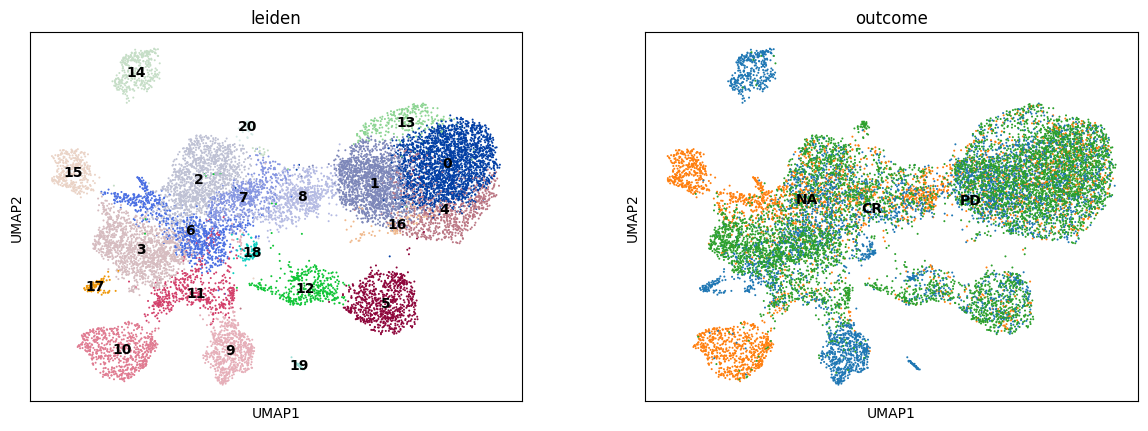

In [224]:
sc.pl.umap(Apexigen_emb_no_HC, color=["leiden",'outcome'], legend_loc="on data")

In [331]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['category'] = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['category'].fillna("Others")

In [333]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['Epitope_and_Type'] = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['Epitope'] + "_" +Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['category']

In [335]:
Apexigen_tumor_paired_train_all_peptide_no_NA_yes_unique_TCR_count_tumor_viral = Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count[Apexigen_tumor_paired_train_all_peptide_no_NA_yes_high_conf_unique_TCR_count['category'].str.contains('Viral|Tumor')]

In [262]:
Apexigen_tumor_paired_train_all_peptide_no_NA_high_prob = Apexigen_tumor_paired_train_all_peptide_no_NA[Apexigen_tumor_paired_train_all_peptide_no_NA['predicted_binding_probability'] > 0.9]

In [264]:
Apexigen_tumor_paired_train_all_peptide_no_NA_high_prob_noHD = Apexigen_tumor_paired_train_all_peptide_no_NA_high_prob[~Apexigen_tumor_paired_train_all_peptide_no_NA_high_prob['patient'].str.contains("HD", na=False)]